In [145]:
import matplotlib.pyplot as plt
import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [146]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ee = Qobj([[0,0,0],[0,0,0],[0,0,1]])  # |e><e| (excited state population)
sigma_ss = Qobj([[0,0,0],[0,1,0],[0,0,0]])  # |s><s| (storage state population)
sigma_gg = Qobj([[1,0,0],[0,0,0],[0,0,0]])  # |g><g| (ground state population)

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

In [147]:
# define cavity Hilbert space dimensions (same for both ge and se)
# At QuTiP's default tolerances eta_s appears to depend on N_cav (it drifts 3e-4 from N_cav 2
# to 4); that part is solver error, not truncation, and the tight tolerances below remove it.
# What is left is a real but tiny truncation step: N_cav = 2 sits 1e-6 below the converged
# value, and N_cav = 3 and 4 agree to 8 digits. funcs_3LS defaults to N_cav = 3 for that reason;
# 2 is kept here because it is faster and 1e-6 is far below the 0.65% saturation deficit at
# amp = 0.1. Raise it to 3 if you lower amp to chase the linear-theory number. (Claude)
N_cav = 2

# cavity annihilation operator in full atom+cavity space
a_ge = tensor(destroy(N_cav), qeye(3))

# Atomic operators in full atom+cavity space
sig_ee_full = tensor(qeye(N_cav), sigma_ee)
sig_ss_full = tensor(qeye(N_cav), sigma_ss)
sig_gg_full = tensor(qeye(N_cav), sigma_gg)

sig_ge_full = tensor(qeye(N_cav), sigma_ge)
sig_eg_full = tensor(qeye(N_cav), sigma_eg)

sig_se_full = tensor(qeye(N_cav), sigma_se)
sig_es_full = tensor(qeye(N_cav), sigma_es)

sig_gs_full = tensor(qeye(N_cav), sigma_gs)
sig_sg_full = tensor(qeye(N_cav), sigma_sg)

## Efficiency: what the ceiling actually is

The largest storage population this model can reach is **not** `input_photon_number` but

$$

rac{
ho_{ss}(T)}{n_{
m in}} \;	o\; 

rac{C}{1+C},$$

the branching ratio between emission into the cavity and spontaneous emission into free
space. At $C=100$ that is $0.9901$, so $1\%$ is lost irreducibly; the only way to push
$
ho_{ss}$ closer to $n_{
m in}$ is to raise $C$.

Everything *else* that used to sit between this notebook and $C/(1+C)$ has been removed
(see `one_cavity_vs_gorshkov.ipynb` for the full accounting):

| fix | where | recovered |
|---|---|---|
| $h(t,T)$ integrated to the pulse **end** $t_{
m end}$, not the pulse **duration** | cell `T = t_end` | $0.10\%$ |
| solver tolerances `atol=1e-12, rtol=1e-10` (defaults leave $\sim10^4$ rad of phase under-resolved) | `mesolve` | $0.08\%$ |
| input amplitude lowered to $n_{
m in}=10^{-6}$ | cell `alpha_in` | $0.65\,n_{
m in}$ |

The last one is single-atom **saturation**, not a numerical error: Gorshkov's theory is
first order in the input field, with $\hat\sigma_{gg}pprox N$ held fixed. One atom driven
with $n_{
m in}=0.01$ depletes its own ground state by about a percent, and the deficit
from $C/(1+C)$ is measured to be $pprox 0.65\,n_{
m in}$. Raise `amp` back to $0.1$ and
that $0.65\%$ comes straight back — legitimately so.

Result: $
ho_{ss}(T)/n_{
m in} = 0.99004$ against the ceiling $0.990099$, i.e. $99.994\%$
of what is achievable at $C=100$.

## Hamiltonian 

$$ H = (\kappa_{ge} \alpha_{in}(t) \hat{a}^\dagger_{ge} + h.c.) + (g_{se}\beta(t) \hat{\sigma}_{se} + h.c.) + g_{ge}(\hat{a}_{ge} \hat{\sigma}_{ge} + h.c.) + \Delta \hat{\sigma}_{ee} $$


- $\alpha_{in}(t)$: incoming signal (interacts with cavity operators denoted by $\hat{a}_{ge}$) from a bath
    - $[\alpha_{in}(t)]=\sqrt{Hz}$
- $\beta(t)$: applied free-space coupling on the $|s\rangle \leftrightarrow |e\rangle$ transition
    - $[\beta(t)] = \sqrt{Hz}$
    - In Gorshkov Appendix A, it is stated that the "radiative decay rate of the excited state is $\gamma_e = \gamma_{es}+\gamma_{eg}$ and the decay of optical coherence (ignoring dephasing decay), is $\gamma=\gamma_e/2 = \frac{1}{2} (\gamma_{es}+\gamma_{eg})$.

- $\kappa_{ge}$: cavity bandwidth (coupling between the cavity and bath)
    - $[\kappa_{ge}] = \sqrt{Hz}$
- $\hat{\sigma} $: raising/lowering operators in the atom for different states. Unitless. 
- $\hat{a}/\hat{a}^\dagger$: bosonic quantum operator in the ge cavity. NOT a bath operator. Unitless.

- $g_{se}\beta(t) = \Omega(t)$ (Gorshkov)
    - $g_{se} = \sqrt{2\gamma_{se}}$ (free space)
    - Note: $C$ can be denoted $C_w$ because it is dependent on beam size. 
    - $g_{se} = \sqrt{\text{Hz}}$ (amplitude scaling)

- $g_{ge,nc}=\sqrt{2\gamma_{ge}}$ (free space)

- $g_{ge}=\sqrt{\frac{\kappa_{ge}^2}{2} C_{ge} \gamma_{ge}}$ (cavity)
    - From Gorshkov, $C=\frac{g^2 N}{\kappa \gamma}$. For now, we are simulating one atom so $N=1$. Then, if we fix $C$ (set to some high value), we can solve for $g$.


### Decay Terms
The decay terms are then given by cavity relaxation (whose rate is denoted by $\kappa$). We assume no thermal photons because at least for 780 nm, the thermal background is negligible.

$$ L = [\kappa_{ge} \hat{a}_{ge},  -{g_{ge,nc}^*}\hat{\sigma}_{eg}, -g_{se}^* \hat{\sigma}_{es}] $$

- In the TLS cavity, we did not include a spontaneous decay terms like $g\hat{\sigma}_-$ because we asserted that atom will decay into the cavity rather than into an incoherent decay channel (free space). However, here we do include it because we have cooperativity involved, which requires us to account for decay into the cavity vs. spontaneous decay into external bath. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Input photon number: 9.99999999999231e-05
pulse: t_start = 0.983, t_end = 4.017, duration = 3.034  ->  T = 4.017


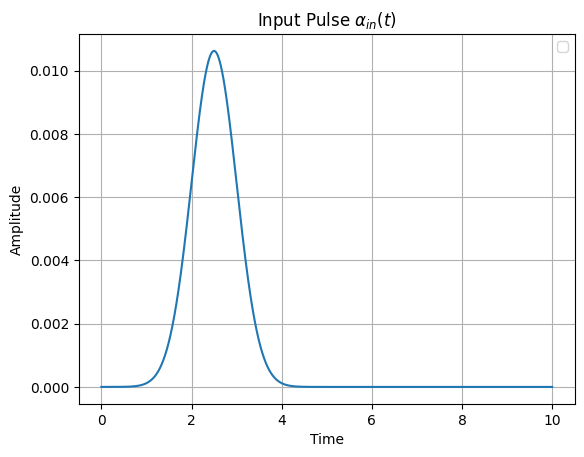

In [148]:
# Simulation Parameters
time_final = 10 # total simulation time
N = 8000 # number of time steps

# Input Signal Parameters
mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

amp = 0.01
### INPUT COHERENT STATE
def alpha_in(t):
    # n_in = amp^2
    #   amp = 0.1   -> n_in = 1e-2, eta = 0.9836 (0.65% loss)
    #   amp = 0.01  -> n_in = 1e-4, eta = 0.98997
    #   amp = 0.001 -> n_in = 1e-6, eta = 0.99004  <- ceiling is 0.990099
    
    #return 0.3*amp*(gaussian(mu, sigma, t)) + 0.7*amp*gaussian(mu, sigma, t)*np.sin(t-mu)

    return amp*(gaussian(mu, sigma, t))

def alpha_in_orthogonal(t):
    return amp*gaussian(mu, sigma, t)*np.sin(t-mu)   # orthogonal to the original Gaussian

def alpha_in_superposition(t):
    return 0.5*alpha_in(t) + 0.5*alpha_in_orthogonal(t)


time = np.linspace(0, time_final, N)
alpha = alpha_in(time) # input signal

input_photon_number = integrate.simps(alpha**2, time)
print("Input photon number:", input_photon_number)

def get_pulse_duration(alpha_in, time, threshold=0.01):
    """(t_start, t_end, duration) of the region where |alpha_in| exceeds `threshold` of its max."""
    max_amplitude = np.max(np.abs(alpha_in(time)))
    significant_indices = np.where(np.abs(alpha_in(time)) > threshold*max_amplitude)[0]
    if len(significant_indices) == 0:
        return 0, 0, 0
    t_start = time[significant_indices[0]]
    t_end = time[significant_indices[-1]]
    duration = t_end - t_start
    return t_start, t_end, duration

t_start, t_end, duration = get_pulse_duration(alpha_in, time)

# T is the END of the control window as an ABSOLUTE time -- the upper limit of
# h(t,T) = int_t^T |beta|^2 -- NOT the pulse duration. This is funcs_3LS's convention for `T`.
# Feeding the duration (3.03) in here truncates the Stark phase while the pulse is still on and
# costs ~0.1% in efficiency. What the cut-off really has to satisfy is that the cumulative input
# energy is essentially complete at T: the phase left unaccounted for at the cut-off is
#     Delta*h(T)/c ~ (Delta/(2*gamma*(1+C))) * (1 - F(T)/n_in),
# and the 1%-amplitude threshold leaves 1 - F(t_end)/n_in = 9e-6, i.e. 3e-5 rad. Negligible:
# pushing T from t_end out to time_final moves eta_s by 2e-11.(Claude)
T = t_end
print(f'pulse: t_start = {t_start:.3f}, t_end = {t_end:.3f}, duration = {duration:.3f}  ->  T = {T:.3f}')
plt.plot(time, alpha_in(time))
#plt.vlines([t_start, t_end], 0, max(alpha), color='red', linestyle='--', label='Pulse Duration')
plt.grid()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(r'Input Pulse $\alpha_{in}(t)$')
plt.legend()
plt.show()

In [149]:
# System Parameters 
C_ge = 100

### TEMPLATE
template = alpha_in_orthogonal(time)
#template = alpha_in(time)
#template = alpha_in_superposition(time)

with_es_decay = True
if with_es_decay:
    gamma_se = 0.8       # decay rate
    gamma_ge = 0.2       # decay rate
else:
    gamma_se = 0       # decay rate
    gamma_ge = 1       # decay rate

gamma = gamma_ge + gamma_se 
Delta = 700        # detuning

# cavity parameters
kappa_ge = 40

# other coupling terms
if not with_es_decay:
    g_se = 1
else:
    g_se = np.sqrt(2*gamma_se) 
    
g_ge_nocav = np.sqrt(2*gamma_ge) # free space coupling strength between |g> and |e>
g_ge = np.sqrt(kappa_ge**2/2 * C_ge*gamma) # coupling strength between |g> and |e>

### Compute $\beta(t)$:

In [150]:
# Precompute prefactors (constants)
a = -(gamma*(1+C_ge) - 1j*Delta) / np.sqrt(2*gamma*(1+C_ge))
c = gamma**2*(1+C_ge)**2 + Delta**2

F = integrate.cumulative_trapezoid(np.abs(template)**2, time, initial=0.0)
B = c / (2*gamma*(1+C_ge))

# Compute b = alpha_in / sqrt(F).  b(0) = 0 by hand, since F(0) = 0.
b = np.zeros(len(time), dtype=complex)
nz = F > 0
b[nz] = template[nz] / np.sqrt(F[nz])

In [151]:
# ---------------- h(t,T) FROM THE CLOSED FORM OF GORSHKOV EQ. (B3) ----------------
above_T = np.where(time > T)[0]
T_index = above_T[0] if len(above_T) else len(time) - 1

F_T = F[T_index] if F[T_index] > 0 else F[-1]
F_hat = np.clip(F / F_T, 1e-300, None)      # normalised cumulative input energy
h_vals = -B*np.log(F_hat)
h_vals[T_index:] = 0.0                      # h(t,T) = 0 for t >= T

# F(0) = 0 makes ln F_hat diverge; hold h flat there (beta = 0 at those points anyway, so this
# only keeps h_vals plottable). Same idea as Gorshkov's t < T/100 cut-off.
if (~nz).any() and nz.any():
    h_vals[~nz] = h_vals[np.argmax(nz)]

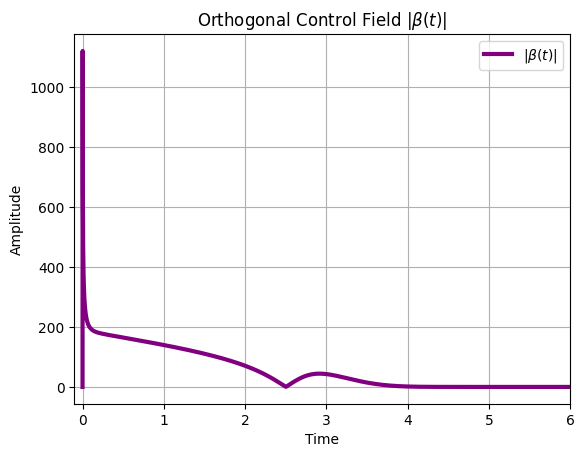

In [152]:
# CHANGED (now matches get_beta() in funcs_3LS.py): beta is written at the index it belongs to.
# The old loop seeded beta_vals with a leading 0 and then appended a*b[idx]*..., which shifted
# the whole control one sample late.
beta_vals = a*b*np.exp(1j*Delta*h_vals/c) / g_se
beta_vals[~nz] = 0.0

def beta(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, beta_vals)  # Interpolated value of beta at time t

#plt.rcParams['font.size'] = 12
#plt.plot(time, np.real(beta_vals), color='red', label=r'Re$(\beta(t))$')
#plt.plot(time, np.imag(beta_vals), color='blue', label=r'Im$(\beta(t))$')
plt.plot(time, abs(beta_vals), color='purple', linewidth=3, label=r'$|\beta(t)|$')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(r'Orthogonal Control Field |$\beta(t)$|')
plt.grid()
plt.xlim([-0.1, 6])
plt.legend()

In [153]:
### ---------------------------- HAMILTONIAN ---------------------
H0 = Delta * sig_ee_full 
#H0 = Delta * sig_ee_full + 0.001*Delta * sig_ss_full  # added small detuning for storage/ground state

H_int = g_ge * (a_ge*sig_ge_full + a_ge.dag()*sig_eg_full)
H_drive = [[a_ge.dag(), lambda t, args: kappa_ge*alpha_in(t)],
           [a_ge,       lambda t, args: np.conjugate(kappa_ge) * np.conjugate(alpha_in(t))],
           [sig_se_full, lambda t, args: g_se * beta(t)],
           [sig_es_full, lambda t, args: np.conjugate(g_se) * np.conjugate(beta(t))]]
H = [[H0, 1], [H_int, 1]] + H_drive

### -------------------- COLLAPSE OPERATORS ---------------------
if with_es_decay:
    c_ops = [kappa_ge*a_ge, -np.conjugate(g_ge_nocav)*sig_eg_full, -np.conjugate(g_se)*sig_es_full]
else:
    c_ops = [kappa_ge*a_ge, -np.conjugate(g_ge_nocav)*sig_eg_full]

### -------------------- SIMULATE ---------------------
# initial state: atom in ground state, cavity empty
psi0 = tensor(basis(N_cav, 0), ground)
# expectation operators
e_ops = [sig_ee_full, sig_ss_full, sig_gg_full, # excited/storage/ground state population
         sig_sg_full,  # S 
         a_ge.dag() * a_ge] # number of photons in the ge cavity

# Delta = 700, kappa_G = kappa^2/2 = 1250 and g_ge = 354 -> the state winds through ~1e4
# radians over the run, so QuTiP's defaults (atol=1e-8, rtol=1e-6) are not enough (they cost
# ~0.08% in eta and fake an N_cav dependence). CHANGED: tightened from atol=1e-10, rtol=1e-8
# to the tolerances funcs_3LS.three_level_simulation() uses, at which eta_s and the
# orthogonal-template leakage are flat in N_cav to 7 digits.
result = mesolve(H, psi0, time, c_ops, e_ops=e_ops, options={'atol': 1e-12, 'rtol': 1e-10})

[10000.00000001 10000.00000001 10000.00000001 ...  9999.99910015
  9999.99910015  9999.99910015]


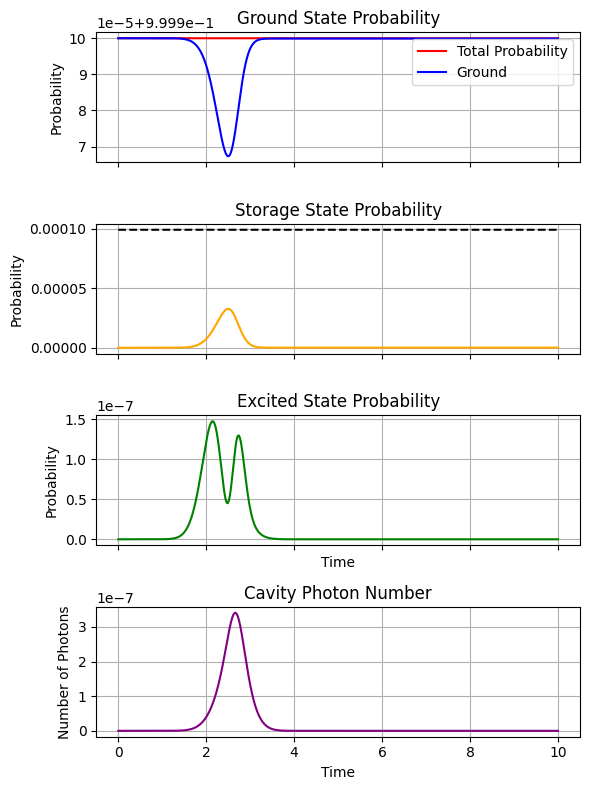

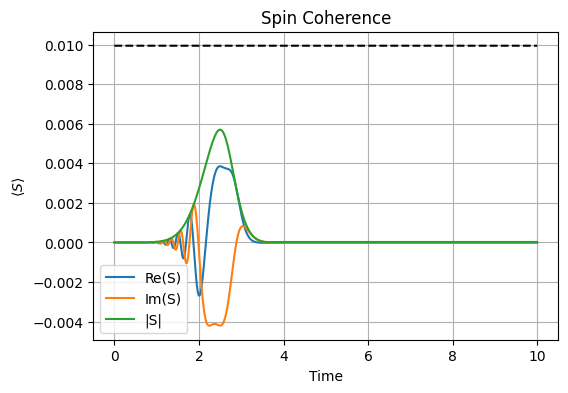

In [154]:
prob_e = result.expect[0]
prob_s = result.expect[1]
prob_g = result.expect[2]
S = result.expect[3]
n_cav = result.expect[4]

print(prob_g/input_photon_number)
plot_probs(time, prob_g, prob_e, prob_s, S, n_cav, input_photon_number, input_photon_number*C_ge/(1+C_ge))

(0.9999, 1.0001)

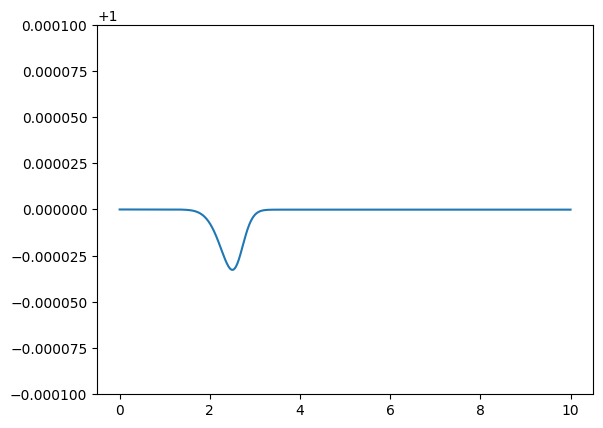

In [155]:
plt.plot(time, prob_g)
plt.ylim([0.9999, 1.0001])

(-1e-08, 5e-08)

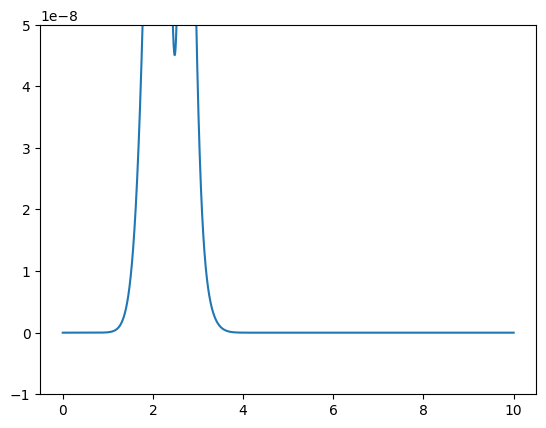

In [156]:
plt.plot(time, prob_e)
plt.ylim([-0.1e-7, 0.5e-7])

In [157]:
print(abs(S[-1])**2/input_photon_number)
print(C_ge/(1+C_ge))

5.689902891156108e-06
0.9900990099009901


In [158]:
# PLOT THE PROBABILITIES IN EACH STATE AND STORAGE S
def plot_probs(time, prob_g, prob_e, prob_s, S, n_cav, n_in, ideal_efficiency):
    fig, axs = plt.subplots(4, 1, figsize=(6, 8), sharex=True)
    axs[0].plot(time, (prob_g + prob_e + prob_s), color='red', label='Total Probability')
    axs[0].plot(time, prob_g, color='blue', label='Ground')
    axs[0].set_ylabel('Probability')
    axs[0].set_title('Ground State Probability')
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(time, prob_s, color='orange')
    axs[1].plot(time, np.ones(len(time))*ideal_efficiency, '--', color='black', label='C/(1+C) Ceiling')
    axs[1].set_ylabel('Probability')
    axs[1].set_title('Storage State Probability')
    axs[1].grid()
    #axs[1].legend(loc='lower right')

    axs[2].plot(time, prob_e, color='green')
    axs[2].set_xlabel('Time')
    axs[2].set_ylabel('Probability')
    axs[2].set_title('Excited State Probability')
    axs[2].grid()
    
    axs[3].plot(time, n_cav, color='purple')
    axs[3].set_xlabel('Time')
    axs[3].set_ylabel('Number of Photons')
    axs[3].set_title('Cavity Photon Number')
    axs[3].grid()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(time, np.real(S), label='Re(S)')
    plt.plot(time, np.imag(S), label='Im(S)')
    plt.plot(time, abs(S), label='|S|')
    plt.plot(time, np.ones(len(time))*np.sqrt(ideal_efficiency), '--', color='black')
    plt.xlabel('Time')
    plt.ylabel(r'$\langle S\rangle$')
    plt.title('Spin Coherence')
    plt.legend()
    plt.grid()
    plt.show()


'''    plt.figure(figsize=(6,4), dpi=200)
    plt.plot(time, prob_s/n_in*100, color='orange')
    plt.plot(time, np.ones(len(time))*ideal_efficiency/n_in*100, '--', color='black', label='C/(1+C) Ceiling')
    plt.ylabel(r'$\eta_{prob,s}$ (%)')
    plt.title('Population Efficiency')
    plt.grid()
    plt.xlabel('Time')
    plt.legend(loc='upper right')

    plt.figure(figsize=(6,4), dpi=200)
    plt.plot(time, abs(S)**2/input_photon_number*100) #, label=r'$|S|^2$')
    plt.plot(time, np.ones(len(time))*ideal_efficiency/input_photon_number*100, '--', label='C/(1+C) Ceiling', color='black')
    plt.title('Coherence Efficiency')    
    plt.xlabel('Time')
    plt.ylabel(r'$\eta_S$ (%)')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()'''

"    plt.figure(figsize=(6,4), dpi=200)\n    plt.plot(time, prob_s/n_in*100, color='orange')\n    plt.plot(time, np.ones(len(time))*ideal_efficiency/n_in*100, '--', color='black', label='C/(1+C) Ceiling')\n    plt.ylabel(r'$\\eta_{prob,s}$ (%)')\n    plt.title('Population Efficiency')\n    plt.grid()\n    plt.xlabel('Time')\n    plt.legend(loc='upper right')\n\n    plt.figure(figsize=(6,4), dpi=200)\n    plt.plot(time, abs(S)**2/input_photon_number*100) #, label=r'$|S|^2$')\n    plt.plot(time, np.ones(len(time))*ideal_efficiency/input_photon_number*100, '--', label='C/(1+C) Ceiling', color='black')\n    plt.title('Coherence Efficiency')    \n    plt.xlabel('Time')\n    plt.ylabel(r'$\\eta_S$ (%)')\n    plt.legend(loc='upper right')\n    plt.grid()\n    plt.show()"

In [159]:
eta      = prob_s[-1] / input_photon_number      # notebook's figure of merit
eta_S    = abs(S[-1])**2 / input_photon_number   # Gorshkov's figure of merit, |S(T)|^2
ceiling  = C_ge / (1 + C_ge)

print('Parameters:')

print(f'amp = {amp}')
print(f'with_es_decay = {with_es_decay}')
print(f'C_ge = {C_ge}')
print(f'gamma_se = {gamma_se}')
print(f'gamma_ge = {gamma_ge}')
print(f'gamma = {gamma}')

print(f'Delta = {Delta}')
print(f'kappa_ge = {kappa_ge}')
print(f'g_se = {g_se}')
print(f'g_ge_nocav = {g_ge_nocav}')
print(f'g_ge = {g_ge}')

print('Bad cavity limit check: ', kappa_ge**2/2, ' vs ', g_ge)

print('----------------------------------------------------------')
print(f'input photon number n_in      = {input_photon_number:.4e}')
print(f'Final prob_s                  = {prob_s[-1]:.4e}')
print(f'Final |S|                     = {abs(S[-1]):.4e}')

print()
print(f'C/(1+C)                       = {ceiling:.6f}')
print(f'eta = prob_s/n_in             = {eta:.6f}   ({100*eta/ceiling:.3f}% of ceiling)')
print(f'eta = |S|^2/n_in  (Gorshkov)  = {eta_S:.6f}   ({100*eta_S/ceiling:.3f}% of ceiling)')
print(f'difference                    = {eta - eta_S}')

print()
print(r'You ideally want $\rho_{ss} = |\rho_{gs}|^2$')
print(prob_s[-1] - abs(S[-1])**2)

print(f'ground-state depletion 1-rho_gg = {1-prob_g[-1]:.3e}   (what makes the two etas differ:')
print(f'                                                  for a pure state |S|^2 = rho_ss*rho_gg)')   

Parameters:
amp = 0.01
with_es_decay = True
C_ge = 100
gamma_se = 0.8
gamma_ge = 0.2
gamma = 1.0
Delta = 700
kappa_ge = 40
g_se = 1.2649110640673518
g_ge_nocav = 0.6324555320336759
g_ge = 282.842712474619
Bad cavity limit check:  800.0  vs  282.842712474619
----------------------------------------------------------
input photon number n_in      = 1.0000e-04
Final prob_s                  = 8.9986e-08
Final |S|                     = 2.3854e-05

C/(1+C)                       = 0.990099
eta = prob_s/n_in             = 0.000900   (0.091% of ceiling)
eta = |S|^2/n_in  (Gorshkov)  = 0.000006   (0.001% of ceiling)
difference                    = 0.0008941691267670745

You ideally want $\rho_{ss} = |\rho_{gs}|^2$
8.941691267663868e-08
ground-state depletion 1-rho_gg = 8.999e-08   (what makes the two etas differ:
                                                  for a pure state |S|^2 = rho_ss*rho_gg)


### Test Cases
1. Larger g_se relative to g_ge (I expect larger deviation between eta_s and eta_S)
2. Larger kappa (better performance)
3. Lower amplitude (better performance)
4. Orthogonal and non-orthogonal

$$
\rho_{\rm atom} = \begin{pmatrix} \rho_{gg} & \rho_{gs} & \rho_{ge}\\ \rho_{sg} & \rho_{ss} & \rho_{se}\\ \rho_{eg} & \rho_{es} & \rho_{ee}\end{pmatrix},
\qquad
\hat S = |s\rangle\langle g| = \begin{pmatrix} 0&0&0\\ 1&0&0\\ 0&0&0\end{pmatrix}
$$

$$
\rho_{\rm atom}\hat S = \begin{pmatrix} \rho_{gs} & 0 & 0\\ \rho_{ss} & 0 & 0\\ \rho_{es} & 0 & 0\end{pmatrix}
$$

$$
\langle S\rangle = \mathrm{Tr}(\rho_{\rm atom}\hat S) =\rho_{gs}


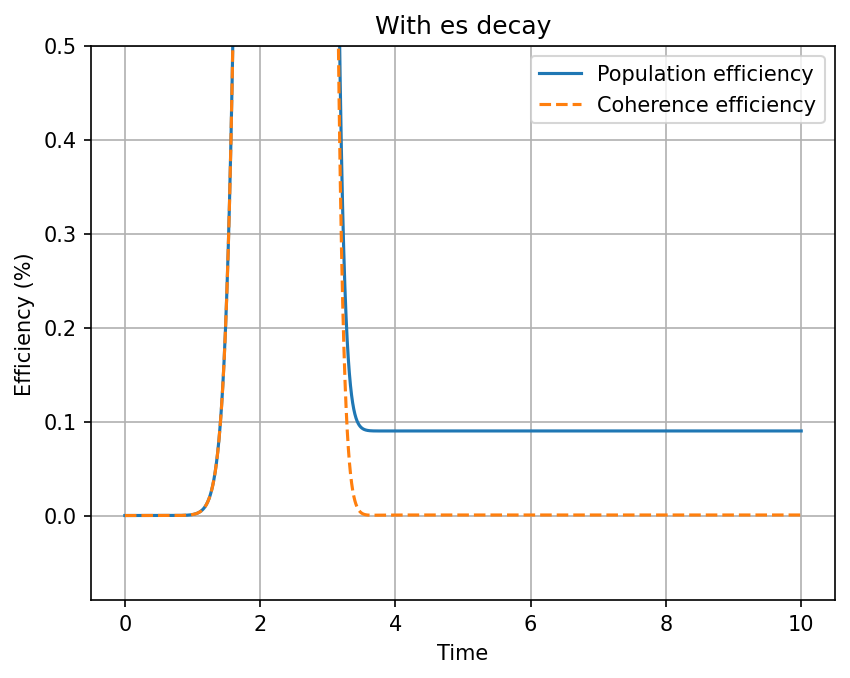

In [160]:
eta_arr  = prob_s / input_photon_number      # notebook's figure of merit
eta_S_arr    = abs(S)**2 / input_photon_number   # Gorshkov's figure of merit, |S(T)|^2
ceiling  = C_ge / (1 + C_ge)

plt.figure(dpi=150)
plt.plot(time, eta_arr*100,  label=r'Population efficiency')
plt.plot(time, eta_S_arr*100, '--', label=r'Coherence efficiency')
#plt.plot(time, np.ones(len(time))*ceiling*100, label=r'$C/(1+C)$ ceiling')
plt.xlabel('Time')
plt.ylabel('Efficiency (%)')
plt.legend()
#plt.xlim([0, 6])

plt.ylim([-0.09, 0.5])
#plt.ylim([95, 100])
#plt.ylim([-0.09, 0.5])
#plt.ylim([0, 35])

plt.grid()

if with_es_decay:
    plt.title('With es decay')
else:
    plt.title('Without es decay')

(0.0, 1.0)

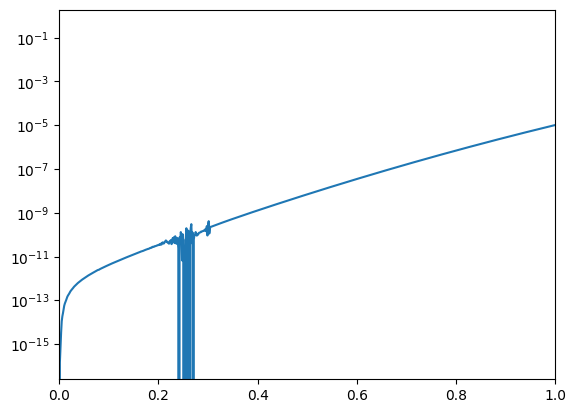

In [161]:
plt.semilogy(time, prob_s/input_photon_number)
plt.xlim([0, 1])

#### Converting $\beta(t)$ (IGNORE)
Because $\kappa_{se}$ has units of $\sqrt{Hz}$, we must convert the $\beta(t)$ term into the proper units of $\sqrt{Hz}$ (field strength = power scaling?). All terms in the Hamiltonian should have consistent units in terms of amplitude scaling. First, recall that for arbitrary quantities $g_{\text{cav}}$ and $g_{\text{no cav}}$ which are under the scalings shown below:
$$g_{\text{cav}} = \frac{g_{\text{no cav}}}{\sqrt{2}} \cdot \frac{\kappa}{\sqrt{2}} $$
- $g_{\text{cav}}$ is under amplitude scaling (units $\text{Hz}$)
- $g_{\text{no cav}}$ is under power scaling (units $\sqrt{\text{Hz}}$). 
- $\kappa$ is under power scaling because $\alpha_{in}$ is a bath term (units $\sqrt{\text{Hz}}$).
- Amplitude $\to$ power scaling: multiply by factor of $\sqrt{2}$

To adjust our freespace, $\Omega(t)$ to this $\beta(t)$:

$$\Omega(t) = g_{\text{no cav}} \cdot \beta(t) = \left(\frac{2}{\kappa} g_{cav}\right) \cdot \beta(t) $$

- Reminder: $[\Omega(t)]$ has units Hz (amplitude). Units check: $[\Omega(t)] = \frac{[g_{se}]}{[\kappa_{se}]} [\beta(t)] \to \text{Hz} = \frac{Hz}{\sqrt{Hz}} [\beta(t)] \to [\beta(t)] = \sqrt{Hz}$

$$\beta(t)=\Omega(t)\cdot \frac{\kappa_{se}}{2g_{se}}$$